In [20]:
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# ✅ 1. 데이터 로드 (Train & Validation)
train_path = "/kaggle/input/unmlve/train_trans.csv"
valid_path = "/kaggle/input/unmlve/valid_250.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

# ✅ 2. 라벨 인코딩 (모든 모델 동일 적용)
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["class"])
valid_df["label"] = label_encoder.transform(valid_df["class"])

# ✅ 3. 하이퍼파라미터 설정 (모든 모델 동일)
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [21]:
from sklearn.metrics import f1_score
import numpy as np

# ✅ 평가 함수 (F1-score, Loss, 일반 대화 개수)
def evaluate_model(model, data_loader, device, label_encoder):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    f1 = f1_score(all_labels, all_preds, average="macro")

    # ✅ "일반 대화" 개수 확인
    general_talk_label = label_encoder.transform(["일반 대화"])[0]
    general_talk_count = np.sum(np.array(all_preds) == general_talk_label)

    print(f"📊 Validation Results - Loss: {avg_loss:.4f}, F1-score: {f1:.4f}, 일반 대화 개수: {general_talk_count}")
    
    return avg_loss, f1, general_talk_count


In [22]:
# ✅ 1.1 Transformer 모델 선택 (환경마다 모델 변경)
MODEL_NAME = "hyunwoongko/kobart"  # ✅ KoBART 적용
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ✅ 1.2 전처리 함수 (max_length=None 설정)
def tokenize_text(texts, tokenizer):
    return tokenizer(
        texts,
        padding='max_length',  # 🔥 max_length=384로 변경
        truncation=True,  # 🔥 384보다 길면 자름
        max_length=384,  
        return_tensors="pt",
    )



train_encodings = tokenize_text(train_df["conversation"].tolist(), tokenizer)
valid_encodings = tokenize_text(valid_df["conversation"].tolist(), tokenizer)

# ✅ 1.3 Dataset 정의
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_dataset = CustomDataset(train_encodings, train_df["label"].tolist())
valid_dataset = CustomDataset(valid_encodings, valid_df["label"].tolist())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ✅ 1.4 Transformer 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5).to(device)

# ✅ 1.5 학습 설정
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = torch.nn.CrossEntropyLoss()

You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels wil be overwritten to 2.
Some weights of BartForSequenceClassification were not initialized from the model checkpoint at hyunwoongko/kobart and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
print(model)

BartForSequenceClassification(
  (model): BartModel(
    (shared): BartScaledWordEmbedding(30000, 768, padding_idx=3)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(30000, 768, padding_idx=3)
      (embed_positions): BartLearnedPositionalEmbedding(1028, 768)
      (layers): ModuleList(
        (0-5): 6 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=768, out_features=768, bias=True)
            (v_proj): Linear(in_features=768, out_features=768, bias=True)
            (q_proj): Linear(in_features=768, out_features=768, bias=True)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (final_la

In [24]:
for param in model.model.encoder.layers[:6].parameters():
    param.requires_grad = False  # ✅ 업데이트 안 함 (Freeze)

for param in model.model.decoder.layers[:6].parameters():
    param.requires_grad = False  # ✅ 업데이트 안 함 (Freeze)


In [25]:
from tqdm import tqdm
import torch

# ✅ 학습 루프 (tqdm 추가)
best_loss = float("inf")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
    
    for batch in loop:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())  # ✅ 현재 배치의 Loss 출력

    avg_loss = total_loss / len(train_loader)
    print(f"\n📊 Epoch {epoch+1} Train Loss: {avg_loss:.4f}")

    # ✅ Validation 평가
    val_loss, val_f1, general_talk_count = evaluate_model(model, valid_loader, device, label_encoder)

    # ✅ 최적 모델 저장 (Validation Loss 기준)
    if val_loss < best_loss:
        best_loss = val_loss
        
        print("✅ Best Model Saved!")
    torch.save(model.state_dict(), f"/kaggle/working/{val_loss:.3f}_trans16_best_model_head.pt")

print("🎉 Training Complete!")


Epoch 1/10: 100%|██████████| 872/872 [08:03<00:00,  1.80it/s, loss=1.36] 



📊 Epoch 1 Train Loss: 0.8995
📊 Validation Results - Loss: 1.8351, F1-score: 0.3922, 일반 대화 개수: 141
✅ Best Model Saved!


Epoch 2/10: 100%|██████████| 872/872 [08:02<00:00,  1.81it/s, loss=0.235]



📊 Epoch 2 Train Loss: 0.6725
📊 Validation Results - Loss: 1.8391, F1-score: 0.4164, 일반 대화 개수: 136


Epoch 3/10: 100%|██████████| 872/872 [08:02<00:00,  1.81it/s, loss=0.252]


...


📊 Epoch 8 Train Loss: 0.2406
📊 Validation Results - Loss: 1.4891, F1-score: 0.5881, 일반 대화 개수: 126


Epoch 9/10: 100%|██████████| 872/872 [08:02<00:00,  1.81it/s, loss=0.235]  



📊 Epoch 9 Train Loss: 0.2055
📊 Validation Results - Loss: 1.5296, F1-score: 0.5923, 일반 대화 개수: 123


Epoch 10/10: 100%|██████████| 872/872 [08:02<00:00,  1.81it/s, loss=0.294]  



📊 Epoch 10 Train Loss: 0.1811
📊 Validation Results - Loss: 1.4425, F1-score: 0.6087, 일반 대화 개수: 120
🎉 Training Complete!


You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels wil be overwritten to 2.
Some weights of BartForSequenceClassification were not initialized from the model checkpoint at hyunwoongko/kobart and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-19-e52c4b0b1c4c>:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be f

📊 테스트 데이터 샘플 확인:
     idx                                               text
0  t_000  아가씨 담배한갑주소 네 4500원입니다 어 네 지갑어디갔지 에이 버스에서 잃어버렸나...
1  t_001  우리팀에서 다른팀으로 갈 사람 없나? 그럼 영지씨가 가는건 어때?  네? 제가요? ...
2  t_002  너 오늘 그게 뭐야 네 제가 뭘 잘못했나요.? 제대로 좀 하지 네 똑바로 좀 하지 ...
3  t_003  이거 들어바 와 이 노래 진짜 좋다 그치 요즘 이 것만 들어 진짜 너무 좋다 내가 ...
4  t_004  아무튼 앞으로 니가 내 와이파이야. .응 와이파이 온. 켰어. 반말? 주인님이라고도...
📊 클래스별 예측 개수:
 class
기타 괴롭힘 대화      136
갈취 대화          112
일반 대화           87
협박 대화           83
직장 내 괴롭힘 대화     82
Name: count, dtype: int64


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44340 (\N{HANGUL SYLLABLE GOE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47213 (\N{HANGUL SYLLABLE ROB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 55192 (\N{HANGUL SYLLABLE HIM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IP

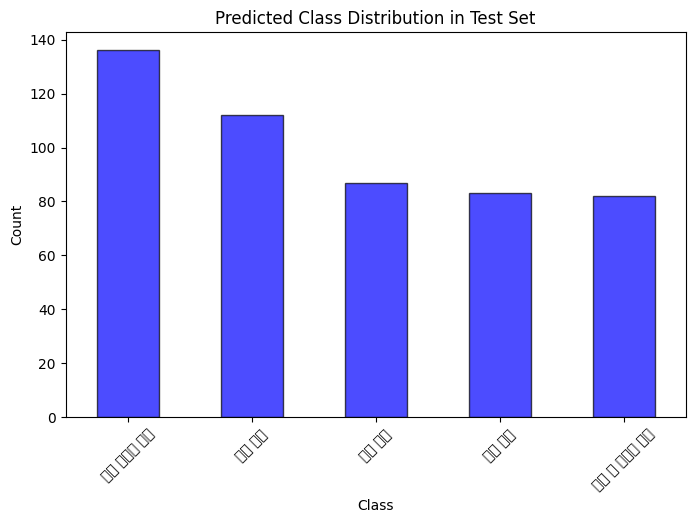

In [19]:
import pandas as pd
last_model_path = "/kaggle/working/1.769_trans16_best_model_head.pt"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5).to(device)
model.load_state_dict(torch.load(last_model_path))  # ✅ 저장된 가중치 불러오기
model.eval()

# ✅ 테스트 데이터 로드
test_path = "/kaggle/input/unmlve/test.csv"
test_df = pd.read_csv(test_path)

print("📊 테스트 데이터 샘플 확인:")
print(test_df.head())

# ✅ 테스트 데이터 전처리 (토크나이저 적용 필요)
def tokenize_text(texts, tokenizer):
    return tokenizer(
        texts,
        padding='max_length',  # 🔥 max_length=384로 변경
        truncation=True,  # 🔥 384보다 길면 자름
        max_length=384,  
        return_tensors="pt",
    )

test_encodings = tokenize_text(test_df["text"].tolist(), tokenizer)

import torch
import numpy as np

# ✅ 예측 수행
model.eval()
test_preds = []

with torch.no_grad():
    for i in range(0, len(test_df), BATCH_SIZE):
        batch_input_ids = test_encodings["input_ids"][i:i+BATCH_SIZE].to(device)
        batch_attention_mask = test_encodings["attention_mask"][i:i+BATCH_SIZE].to(device)

        outputs = model(batch_input_ids, attention_mask=batch_attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        test_preds.extend(preds.cpu().numpy())

# ✅ 예측된 클래스 복원 (LabelEncoder 사용)
test_df["class"] = label_encoder.inverse_transform(test_preds)

# ✅ 각 클래스별 예측 개수 출력
class_distribution = test_df["class"].value_counts()
print("📊 클래스별 예측 개수:\n", class_distribution)

# ✅ 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
class_distribution.plot(kind="bar", color="blue", edgecolor="black", alpha=0.7)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution in Test Set")
plt.xticks(rotation=45)
plt.show()


In [2]:
from datasets import load_dataset
from tqdm.auto import tqdm

# NSMC 데이터셋 불러오기 (train, test 포함)
dataset = load_dataset("nsmc")

# 데이터셋 크기 확인
print(f"Train 데이터 개수: {len(dataset['train'])}")
print(f"Test 데이터 개수: {len(dataset['test'])}")

# Train 데이터를 90% Train, 10% Validation으로 분리
split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset['train']
val_dataset = split_dataset['test']

print(f"Train 데이터 크기: {len(train_dataset)}")
print(f"Validation 데이터 크기: {len(val_dataset)}")

# tqdm으로 데이터 확인해보기
print("Train 데이터 샘플 확인:")
for i in tqdm(range(5)):
    print(train_dataset[i])




README.md:   0%|          | 0.00/3.74k [00:00<?, ?B/s]

nsmc.py:   0%|          | 0.00/3.18k [00:00<?, ?B/s]

The repository for nsmc contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/nsmc.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


Generating train split:   0%|          | 0/150000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train 데이터 개수: 150000
Test 데이터 개수: 50000
Train 데이터 크기: 135000
Validation 데이터 크기: 15000
Train 데이터 샘플 확인:


  0%|          | 0/5 [00:00<?, ?it/s]

{'id': '5960467', 'document': '명작은 옛날과 현재의 동일한 공감대 위에 놓인다. 그리고 더스틴 호프만의 섹시미^^', 'label': 1}
{'id': '5244343', 'document': '원작에 미원을 치다.', 'label': 0}
{'id': '8786278', 'document': '경상도로 하고싶었지만 티날까봐강원도로 하셨나? 가만있는 강원도만불쌍하게 된겨?', 'label': 0}
{'id': '5452084', 'document': '나래이션 미쳤다 KBS 나레이션은 진짜 멋졌다!! 극장나래이션은 별점이아깝다!', 'label': 0}
{'id': '10045037', 'document': '영화 자체도 좋았지만. 아오이유우 때문에 모에사 할뻔했다.', 'label': 1}


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Train 데이터 토큰 길이 측정 중...


  0%|          | 0/135000 [00:00<?, ?it/s]

Validation 데이터 토큰 길이 측정 중...


  0%|          | 0/15000 [00:00<?, ?it/s]

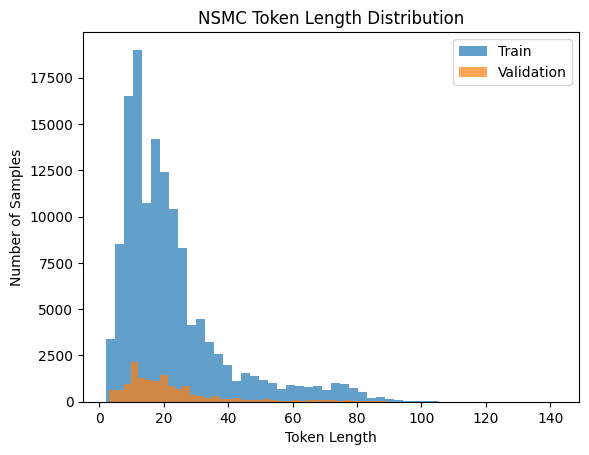

Train 최대 길이: 142, 평균 길이: 22
Validation 최대 길이: 117, 평균 길이: 22


In [3]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

# 1. Tokenizer 불러오기 (KLUE BERT 예시, 네가 쓰고 있는 모델로 맞춰도 됨)
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 2. Train 데이터셋의 문장 길이 측정
train_lengths = []

print("Train 데이터 토큰 길이 측정 중...")
for example in tqdm(train_dataset):
    tokens = tokenizer(example['document'], truncation=False, padding=False)
    length = len(tokens['input_ids'])
    train_lengths.append(length)

# 3. Validation 데이터셋도 동일하게
val_lengths = []

print("Validation 데이터 토큰 길이 측정 중...")
for example in tqdm(val_dataset):
    tokens = tokenizer(example['document'], truncation=False, padding=False)
    length = len(tokens['input_ids'])
    val_lengths.append(length)

# 4. 히스토그램 시각화
plt.hist(train_lengths, bins=50, alpha=0.7, label='Train')
plt.hist(val_lengths, bins=50, alpha=0.7, label='Validation')
plt.xlabel('Token Length')
plt.ylabel('Number of Samples')
plt.title('NSMC Token Length Distribution')
plt.legend()
plt.show()

# 최대, 평균 길이도 확인
print(f"Train 최대 길이: {max(train_lengths)}, 평균 길이: {sum(train_lengths)//len(train_lengths)}")
print(f"Validation 최대 길이: {max(val_lengths)}, 평균 길이: {sum(val_lengths)//len(val_lengths)}")


In [4]:
import numpy as np

# 95% 길이 기준 확인
train_95 = int(np.percentile(train_lengths, 95))
val_95 = int(np.percentile(val_lengths, 95))

print(f"Train 데이터 95% 길이 이하: {train_95} tokens")
print(f"Validation 데이터 95% 길이 이하: {val_95} tokens")


Train 데이터 95% 길이 이하: 62 tokens
Validation 데이터 95% 길이 이하: 62 tokens


In [ ]:
def preprocess_function_dynamic(examples):
    return tokenizer(
        examples['document'],
        padding=False,      # 패딩 제거
        truncation=True,
        max_length=128      # 너무 긴 문장은 자름, 하지만 패딩은 안 함
    )

# 버켓팅용 데이터
train_dataset_dynamic = split_dataset['train'].map(preprocess_function_dynamic, batched=True)
val_dataset_dynamic = split_dataset['test'].map(preprocess_function_dynamic, batched=True)

train_dataset_dynamic = train_dataset_dynamic.remove_columns(['id', 'document'])
val_dataset_dynamic = val_dataset_dynamic.remove_columns(['id', 'document'])

train_dataset_dynamic.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'label'])
val_dataset_dynamic.set_format(type='torch', columns=['input_ids', 'token_type_ids', 'attention_mask', 'label'])
